TASK 1: MCP NEURON
AND Gate Output: [0, 0, 0, 1]
OR Gate Output: [0, 1, 1, 1]
XOR Output (logic-based): [0, 1, 1, 0]

Please upload the required CSV dataset files now.
Recommended file names:
1. mnist_0_and_1.csv
2. mnist_3_and_5.csv


Saving mnist_0_and_1.csv to mnist_0_and_1.csv
Saving mnist_3_and_5.csv to mnist_3_and_5.csv

Detected files:
Task 2 file: mnist_0_and_1.csv
Task 3 file: mnist_3_and_5.csv
TASK: Perceptron Classification for 0 vs 1
Labels found in dataset: [np.int64(0), np.int64(1)]
Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


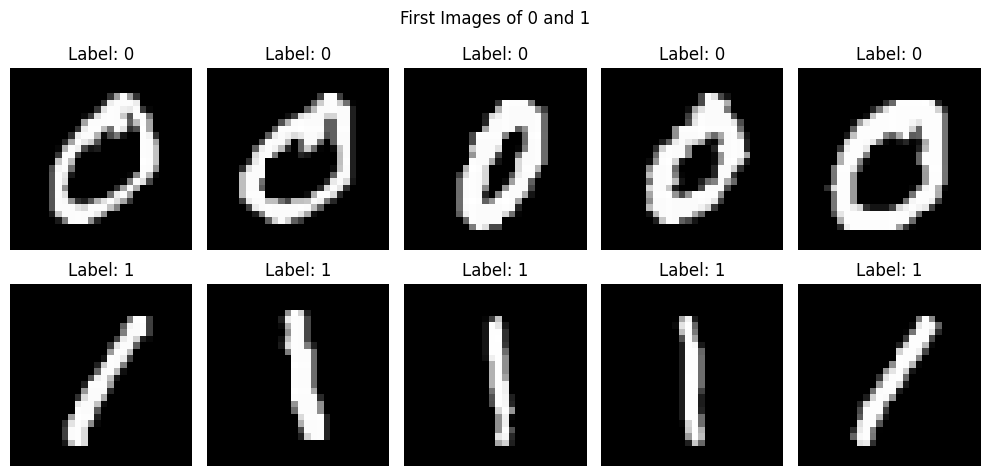

Initial weights shape: (784,)
Initial bias: 0.0
Epoch 1/100 - Accuracy: 0.9962
Epoch 2/100 - Accuracy: 0.9982
Epoch 3/100 - Accuracy: 0.9984
Epoch 4/100 - Accuracy: 0.9993
Epoch 5/100 - Accuracy: 0.9991
Epoch 6/100 - Accuracy: 0.9995
Epoch 7/100 - Accuracy: 1.0000
Training converged early.
Final Accuracy: 1.0
Final Accuracy (recomputed): 1.0000
Total misclassified images: 0
All images were correctly classified!
Example prediction for first image: 0
True label for first image: 0
TASK: Perceptron Classification for 3 vs 5
Labels found in dataset: [np.int64(3), np.int64(5)]
Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


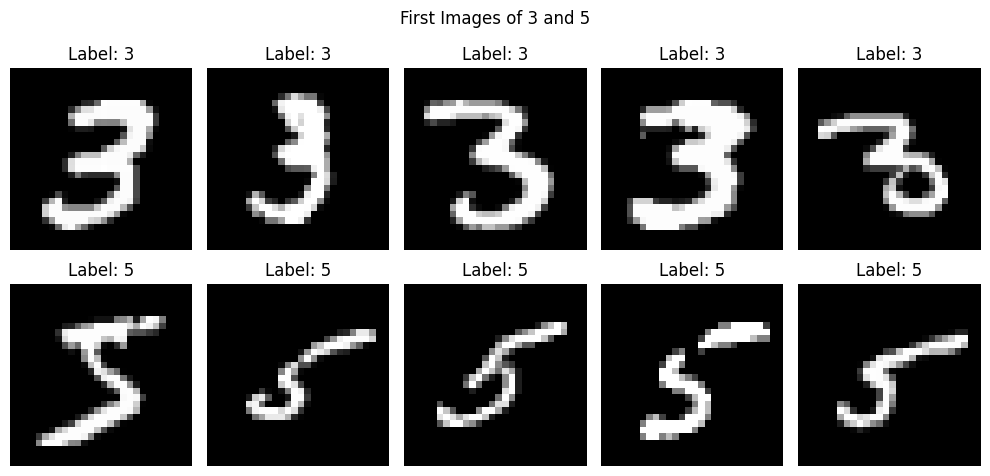

Initial weights shape: (784,)
Initial bias: 0.0
Epoch 1/100 - Accuracy: 0.9084
Epoch 2/100 - Accuracy: 0.9438
Epoch 3/100 - Accuracy: 0.9438
Epoch 4/100 - Accuracy: 0.9435
Epoch 5/100 - Accuracy: 0.9518
Epoch 6/100 - Accuracy: 0.9533
Epoch 7/100 - Accuracy: 0.9559
Epoch 8/100 - Accuracy: 0.9591
Epoch 9/100 - Accuracy: 0.9573
Epoch 10/100 - Accuracy: 0.9588
Epoch 11/100 - Accuracy: 0.9599
Epoch 12/100 - Accuracy: 0.9591
Epoch 13/100 - Accuracy: 0.9642
Epoch 14/100 - Accuracy: 0.9657
Epoch 15/100 - Accuracy: 0.9642
Epoch 16/100 - Accuracy: 0.9646
Epoch 17/100 - Accuracy: 0.9704
Epoch 18/100 - Accuracy: 0.9639
Epoch 19/100 - Accuracy: 0.9697
Epoch 20/100 - Accuracy: 0.9690
Epoch 21/100 - Accuracy: 0.9661
Epoch 22/100 - Accuracy: 0.9708
Epoch 23/100 - Accuracy: 0.9668
Epoch 24/100 - Accuracy: 0.9715
Epoch 25/100 - Accuracy: 0.9683
Epoch 26/100 - Accuracy: 0.9701
Epoch 27/100 - Accuracy: 0.9694
Epoch 28/100 - Accuracy: 0.9701
Epoch 29/100 - Accuracy: 0.9715
Epoch 30/100 - Accuracy: 0.9723
E

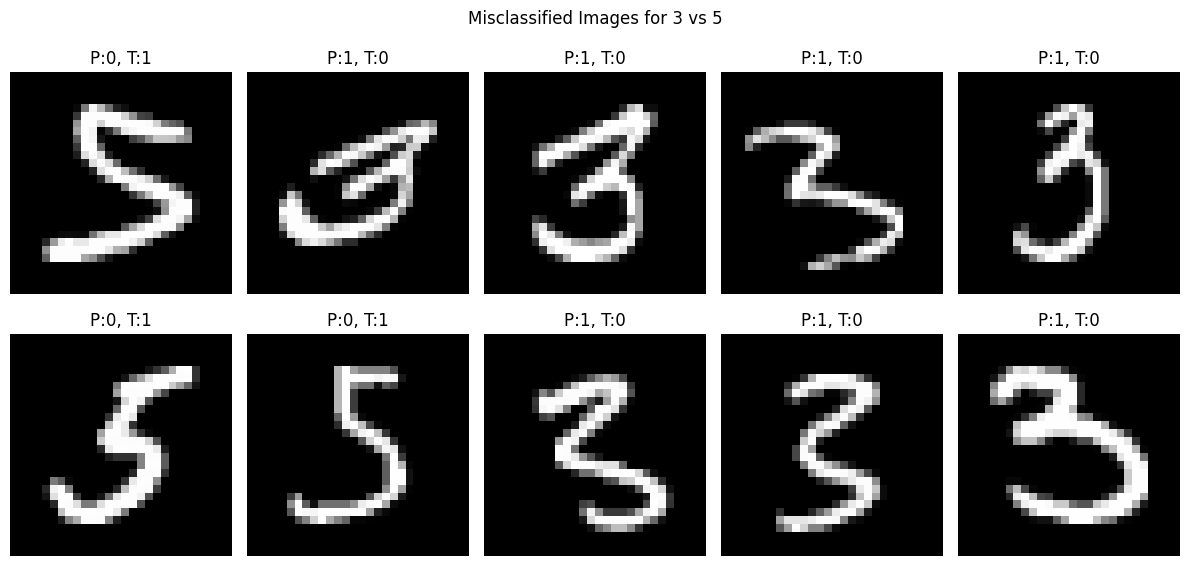

Example prediction for first image: 5
True label for first image: 5


In [3]:



import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# GOOGLE COLAB FILE UPLOAD
# ============================================================
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ============================================================
# TASK 1: MCP NEURON FOR AND / OR
# ============================================================

def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)
    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)
    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


def MCP_XOR_logic(X1, X2):
    assert len(X1) == len(X2)
    outputs = []

    for a, b in zip(X1, X2):
        if a == 0 and b == 0:
            outputs.append(0)
        elif a == 0 and b == 1:
            outputs.append(1)
        elif a == 1 and b == 0:
            outputs.append(1)
        else:
            outputs.append(0)

    return outputs


print("============================================================")
print("TASK 1: MCP NEURON")
print("============================================================")

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

T_and = 2
result_and = MCP_Neurons_AND(X1, X2, T_and)
print(f"AND Gate Output: {result_and}")

T_or = 1
result_or = MCP_Neurons_OR(X1, X2, T_or)
print(f"OR Gate Output: {result_or}")

result_xor = MCP_XOR_logic(X1, X2)
print(f"XOR Output (logic-based): {result_xor}")


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    return np.where(predictions >= 0, 1, 0)


def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    n_samples = X.shape[0]

    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(n_samples):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0
            error = y[i] - y_pred

            if error != 0:
                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error
            else:
                correct_predictions += 1

        accuracy = correct_predictions / n_samples
        print(f"Epoch {epoch + 1}/{epochs} - Accuracy: {accuracy:.4f}")

        if accuracy == 1.0:
            print("Training converged early.")
            break

    final_predictions = decision_function(X, weights, bias)
    accuracy = np.mean(final_predictions == y)

    return weights, bias, accuracy


def visualize_images_by_label(X, y, label_a=0, label_b=1, title_text="Sample Images"):
    images_a = X[y == label_a]
    images_b = X[y == label_b]

    count_a = min(5, len(images_a))
    count_b = min(5, len(images_b))
    count = min(count_a, count_b)

    if count == 0:
        print(f"Cannot display images for labels {label_a} and {label_b}.")
        return

    fig, axes = plt.subplots(2, count, figsize=(2 * count, 5))

    if count == 1:
        axes = np.array(axes).reshape(2, 1)

    for i in range(count):
        axes[0, i].imshow(images_a[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title(f"Label: {label_a}")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_b[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title(f"Label: {label_b}")
        axes[1, i].axis("off")

    plt.suptitle(title_text)
    plt.tight_layout()
    plt.show()


def visualize_misclassified_images(X, y_true, y_pred, max_images=10, title_text="Misclassified Images"):
    misclassified_idx = np.where(y_pred != y_true)[0]
    print(f"Total misclassified images: {len(misclassified_idx)}")

    if len(misclassified_idx) == 0:
        print("All images were correctly classified!")
        return

    display_count = min(max_images, len(misclassified_idx))
    rows = (display_count + 4) // 5
    cols = min(5, display_count)

    plt.figure(figsize=(12, 3 * rows))

    for i, idx in enumerate(misclassified_idx[:display_count]):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.title(f"P:{y_pred[idx]}, T:{y_true[idx]}")
        plt.axis("off")

    plt.suptitle(title_text)
    plt.tight_layout()
    plt.show()


def validate_dataset(df, label_a, label_b):
    if "label" not in df.columns:
        raise ValueError("Dataset must contain a column named 'label'.")

    unique_labels = sorted(df["label"].unique())
    print("Labels found in dataset:", unique_labels)

    if label_a not in unique_labels or label_b not in unique_labels:
        raise ValueError(f"Dataset must contain labels {label_a} and {label_b}.")

    feature_cols = [col for col in df.columns if col != "label"]
    if len(feature_cols) != 784:
        print(f"Warning: Expected 784 pixel columns, found {len(feature_cols)} columns.")
        print("This code expects MNIST-style 28x28 flattened images.")


def run_perceptron_task(csv_path, label_a, label_b, learning_rate=0.1, epochs=100):
    print("============================================================")
    print(f"TASK: Perceptron Classification for {label_a} vs {label_b}")
    print("============================================================")

    df = pd.read_csv(csv_path)
    validate_dataset(df, label_a, label_b)

    # Keep only the required two labels
    df = df[df["label"].isin([label_a, label_b])].copy()

    X = df.drop(columns=["label"]).values
    y_original = df["label"].values

    # Normalize pixel values if needed
    if X.max() > 1:
        X = X / 255.0

    # Convert labels to binary
    y = np.where(y_original == label_b, 1, 0)

    print("Feature matrix shape:", X.shape)
    print("Label vector shape:", y_original.shape)

    visualize_images_by_label(
        X, y_original,
        label_a=label_a,
        label_b=label_b,
        title_text=f"First Images of {label_a} and {label_b}"
    )

    weights = np.zeros(X.shape[1])
    bias = 0.0

    print("Initial weights shape:", weights.shape)
    print("Initial bias:", bias)

    weights, bias, accuracy = train_perceptron(
        X, y, weights, bias,
        learning_rate=learning_rate,
        epochs=epochs
    )

    print("Final Accuracy:", accuracy)

    y_pred = decision_function(X, weights, bias)
    final_accuracy = np.mean(y_pred == y)
    print(f"Final Accuracy (recomputed): {final_accuracy:.4f}")

    visualize_misclassified_images(
        X, y, y_pred,
        max_images=10,
        title_text=f"Misclassified Images for {label_a} vs {label_b}"
    )

    sample_index = 0
    sample_output = np.dot(X[sample_index], weights) + bias
    sample_pred = 1 if sample_output >= 0 else 0
    mapped_pred = label_b if sample_pred == 1 else label_a

    print(f"Example prediction for first image: {mapped_pred}")
    print(f"True label for first image: {y_original[sample_index]}")

    return weights, bias, final_accuracy


# ============================================================
# FILE UPLOAD / FILE DETECTION
# ============================================================

def upload_required_csvs():
    """
    Upload CSV files in Google Colab.
    Expected files:
    - mnist_0_and_1.csv
    - mnist_3_and_5.csv
    """
    uploaded_files = {}

    if IN_COLAB:
        print("\nPlease upload the required CSV dataset files now.")
        print("Recommended file names:")
        print("1. mnist_0_and_1.csv")
        print("2. mnist_3_and_5.csv")
        uploaded = files.upload()

        for filename in uploaded.keys():
            uploaded_files[filename] = filename
    else:
        print("Not running in Google Colab.")
        print("Make sure the CSV files are in the same folder as this notebook/script.")

    return uploaded_files


def find_csv_file(possible_names):
    """
    Find a CSV file from a list of possible names.
    """
    for name in possible_names:
        if os.path.exists(name):
            return name
    return None


# ============================================================
# UPLOAD DATASETS
# ============================================================

uploaded_files = upload_required_csvs()

# Possible names for task 2
task2_names = [
    "mnist_0_and_1.csv",
    "MNIST_0_and_1.csv",
    "0_and_1.csv"
]

# Possible names for task 3
task3_names = [
    "mnist_3_and_5.csv",
    "MNIST_3_and_5.csv",
    "3_and_5.csv"
]

task2_file = find_csv_file(task2_names)
task3_file = find_csv_file(task3_names)

print("\nDetected files:")
print("Task 2 file:", task2_file)
print("Task 3 file:", task3_file)


# ============================================================
# TASK 2: PERCEPTRON FOR 0 vs 1 CLASSIFICATION
# ============================================================

if task2_file is not None:
    try:
        weights_01, bias_01, acc_01 = run_perceptron_task(
            csv_path=task2_file,
            label_a=0,
            label_b=1,
            learning_rate=0.1,
            epochs=100
        )
    except Exception as e:
        print("Error while running Task 2:", e)
else:
    print("Task 2 dataset file not found.")
    print("Please upload mnist_0_and_1.csv")


# ============================================================
# TASK 3: PERCEPTRON FOR 3 vs 5 CLASSIFICATION
# ============================================================

if task3_file is not None:
    try:
        weights_35, bias_35, acc_35 = run_perceptron_task(
            csv_path=task3_file,
            label_a=3,
            label_b=5,
            learning_rate=0.1,
            epochs=100
        )
    except Exception as e:
        print("Error while running Task 3:", e)
else:
    print("Task 3 dataset file not found.")
    print("Please upload mnist_3_and_5.csv")